<a href="https://colab.research.google.com/github/arthisri2810-dot/driver-drowsiness-detection/blob/main/Driver_Drowsiness_Detection_using_Eye_Closure_and_Yawning_Analysis_with_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required libraries
!pip install -q tensorflow matplotlib seaborn scikit-learn pandas

In [2]:
!pip install mediapipe==0.10.20

In [3]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [12]:
import os
import shutil
import random

random.seed(42)

base_path = "/content/train"
new_base = "/content"

val_path = os.path.join(new_base, "val")
test_path = os.path.join(new_base, "test")

os.makedirs(val_path, exist_ok=True)
os.makedirs(test_path, exist_ok=True)

for category in os.listdir(base_path):

    cat_path = os.path.join(base_path, category)

    if not os.path.isdir(cat_path):
        continue

    val_cat = os.path.join(val_path, category)
    test_cat = os.path.join(test_path, category)

    os.makedirs(val_cat, exist_ok=True)
    os.makedirs(test_cat, exist_ok=True)

    images = [
        img for img in os.listdir(cat_path)
        if img.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    random.shuffle(images)

    val_split = int(0.1 * len(images))
    test_split = int(0.1 * len(images))

    val_imgs = images[:val_split]
    test_imgs = images[val_split:val_split + test_split]

    # ✅ MOVE instead of COPY
    for img in val_imgs:
        shutil.move(
            os.path.join(cat_path, img),
            os.path.join(val_cat, img)
        )

    for img in test_imgs:
        shutil.move(
            os.path.join(cat_path, img),
            os.path.join(test_cat, img)
        )

print("✅ Proper Train/Val/Test split completed!")

✅ Proper Train/Val/Test split completed!


In [13]:
import os
import shutil
import random

random.seed(42)

# ✅ FIXED PATHS
base_path = "/content/train"
new_base = "/content"

# Create val & test folders
for split in ['val', 'test']:
    os.makedirs(os.path.join(new_base, split), exist_ok=True)

for category in os.listdir(base_path):

    cat_path = os.path.join(base_path, category)

    if not os.path.isdir(cat_path):
        continue

    val_cat = os.path.join(new_base, "val", category)
    test_cat = os.path.join(new_base, "test", category)

    os.makedirs(val_cat, exist_ok=True)
    os.makedirs(test_cat, exist_ok=True)

    # ✅ Filter only images
    images = [
        img for img in os.listdir(cat_path)
        if img.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    random.shuffle(images)

    val_split = int(0.1 * len(images))
    test_split = int(0.1 * len(images))

    val_imgs = images[:val_split]
    test_imgs = images[val_split:val_split + test_split]

    # ✅ MOVE instead of COPY (IMPORTANT)
    for img in val_imgs:
        shutil.move(
            os.path.join(cat_path, img),
            os.path.join(val_cat, img)
        )

    for img in test_imgs:
        shutil.move(
            os.path.join(cat_path, img),
            os.path.join(test_cat, img)
        )

print("✅ Proper val & test created (no data leakage)")

✅ Proper val & test created (no data leakage)


In [14]:
# ==============================
# Dataset Paths + Verification
# ==============================

import os

train_path = "/content/train"
val_path   = "/content/val"
test_path  = "/content/test"

# Check paths exist
for path in [train_path, val_path, test_path]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ {path} not found")

print("✅ All dataset paths exist")

# Show class folders
print("\n📂 Train Classes:", os.listdir(train_path))
print("📂 Validation Classes:", os.listdir(val_path))
print("📂 Test Classes:", os.listdir(test_path))

# Count images per class
def count_images(folder):
    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            print(f"{cls}: {len(os.listdir(cls_path))} images")

print("\n📊 Train Distribution:")
count_images(train_path)

print("\n📊 Validation Distribution:")
count_images(val_path)

print("\n📊 Test Distribution:")
count_images(test_path)

✅ All dataset paths exist

📂 Train Classes: ['no_yawn', 'Closed', 'Open', 'yawn']
📂 Validation Classes: ['no_yawn', 'Closed', 'Open', 'yawn']
📂 Test Classes: ['no_yawn', 'Closed', 'Open', 'yawn']

📊 Train Distribution:
no_yawn: 465 images
Closed: 466 images
Open: 466 images
yawn: 465 images

📊 Validation Distribution:
no_yawn: 130 images
Closed: 130 images
Open: 130 images
yawn: 129 images

📊 Test Distribution:
no_yawn: 130 images
Closed: 130 images
Open: 130 images
yawn: 129 images


In [15]:
# ==============================
# Split Dataset into Eye & Mouth Models
# ==============================

import os
import shutil

# ✅ FIXED PATH
base_path = "/content"

eye_classes = ['open', 'closed']
mouth_classes = ['yawn', 'no_yawn']

# Remove old folders if exist
shutil.rmtree('/content/eye', ignore_errors=True)
shutil.rmtree('/content/mouth', ignore_errors=True)

for split in ['train', 'val', 'test']:

    split_path = os.path.join(base_path, split)

    for cls in os.listdir(split_path):

        src = os.path.join(split_path, cls)
        cls_lower = cls.lower()

        # Skip non-folders
        if not os.path.isdir(src):
            continue

        # Assign destination
        if cls_lower in eye_classes:
            dst = f"/content/eye/{split}/{cls_lower}"
        elif cls_lower in mouth_classes:
            dst = f"/content/mouth/{split}/{cls_lower}"
        else:
            continue

        os.makedirs(dst, exist_ok=True)

        for file in os.listdir(src):
            src_file = os.path.join(src, file)

            # Only copy images
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                shutil.copy(src_file, os.path.join(dst, file))

print("✅ Dataset split into Eye & Mouth models")

✅ Dataset split into Eye & Mouth models


In [16]:
print("Eye Train:", os.listdir('/content/eye/train'))
print("Mouth Train:", os.listdir('/content/mouth/train'))

Eye Train: ['open', 'closed']
Mouth Train: ['no_yawn', 'yawn']


In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# ==============================
# Data Generators
# ==============================

# 🔥 MobileNet preprocessing
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.1,
    brightness_range=[0.8, 1.2]
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

# ==============================
# Eye Model Data (lighter augmentation)
# ==============================

eye_train = train_gen.flow_from_directory(
    '/content/eye/train',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    seed=42
)

eye_val = val_gen.flow_from_directory(
    '/content/eye/val',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

eye_test = test_gen.flow_from_directory(
    '/content/eye/test',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# ==============================
# Mouth Model Data (stronger augmentation)
# ==============================

mouth_train = train_gen.flow_from_directory(
    '/content/mouth/train',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    seed=42
)

mouth_val = val_gen.flow_from_directory(
    '/content/mouth/val',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

mouth_test = test_gen.flow_from_directory(
    '/content/mouth/test',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# ==============================
# Verification
# ==============================

print("Eye Classes:", eye_train.class_indices)
print("Mouth Classes:", mouth_train.class_indices)

print("Eye Train Samples:", eye_train.samples)
print("Mouth Train Samples:", mouth_train.samples)

Found 932 images belonging to 2 classes.
Found 260 images belonging to 2 classes.
Found 260 images belonging to 2 classes.
Found 930 images belonging to 2 classes.
Found 259 images belonging to 2 classes.
Found 259 images belonging to 2 classes.
Eye Classes: {'closed': 0, 'open': 1}
Mouth Classes: {'no_yawn': 0, 'yawn': 1}
Eye Train Samples: 932
Mouth Train Samples: 930


In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# ==============================
# Data Preprocessing
# ==============================

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,   # 🔥 FIXED
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    width_shift_range=0.05,
    height_shift_range=0.05
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

# ==============================
# Eye Model Data
# ==============================

eye_train = train_gen.flow_from_directory(
    '/content/eye/train',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    seed=42
)

eye_val = val_gen.flow_from_directory(
    '/content/eye/val',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

eye_test = test_gen.flow_from_directory(
    '/content/eye/test',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# ==============================
# Mouth Model Data
# ==============================

mouth_train = train_gen.flow_from_directory(
    '/content/mouth/train',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    seed=42
)

mouth_val = val_gen.flow_from_directory(
    '/content/mouth/val',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

mouth_test = test_gen.flow_from_directory(
    '/content/mouth/test',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# ==============================
# Labels (for inference / Streamlit)
# ==============================

eye_labels = list(eye_train.class_indices.keys())
mouth_labels = list(mouth_train.class_indices.keys())

print("Eye Labels:", eye_labels)
print("Mouth Labels:", mouth_labels)

Found 932 images belonging to 2 classes.
Found 260 images belonging to 2 classes.
Found 260 images belonging to 2 classes.
Found 930 images belonging to 2 classes.
Found 259 images belonging to 2 classes.
Found 259 images belonging to 2 classes.
Eye Labels: ['closed', 'open']
Mouth Labels: ['no_yawn', 'yawn']


In [19]:
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam

def build_cnn():

    model = models.Sequential([

        layers.Input(shape=(224,224,3)),

        # Block 1
        layers.Conv2D(32, (3,3), padding='same',
                      kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),

        # Block 2
        layers.Conv2D(64, (3,3), padding='same',
                      kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),

        # Block 3
        layers.Conv2D(128, (3,3), padding='same',
                      kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),

        # Block 4
        layers.Conv2D(256, (3,3), padding='same',
                      kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),

        # Feature reduction
        layers.GlobalAveragePooling2D(),

        # Dense layers
        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.5),

        layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.4),

        layers.Dense(2, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# Create models
eye_model = build_cnn()
mouth_model = build_cnn()

print("✅ Improved CNN models ready")

✅ Improved CNN models ready


In [20]:

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# ==============================
# Train Eye Model
# ==============================

print("\n===== Training Eye Model =====")

eye_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

eye_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

eye_checkpoint = ModelCheckpoint(
    "best_eye_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

eye_history = eye_model.fit(
    eye_train,
    validation_data=eye_val,
    epochs=15,   # 🔥 increased
    callbacks=[eye_early_stop, eye_reduce_lr, eye_checkpoint],
    verbose=1
)


# ==============================
# Train Mouth Model
# ==============================

print("\n===== Training Mouth Model =====")

# 🔥 Compute class weights (IMPORTANT)
labels = mouth_train.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print("Mouth Class Weights:", class_weights)

mouth_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

mouth_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

mouth_checkpoint = ModelCheckpoint(
    "best_mouth_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

mouth_history = mouth_model.fit(
    mouth_train,
    validation_data=mouth_val,
    epochs=20,   # 🔥 more epochs
    class_weight=class_weights,   # 🔥 KEY FIX
    callbacks=[mouth_early_stop, mouth_reduce_lr, mouth_checkpoint],
    verbose=1
)


===== Training Eye Model =====
Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5239 - loss: 1.2587
Epoch 1: val_accuracy improved from None to 0.55769, saving model to best_eye_model.keras

Epoch 1: finished saving model to best_eye_model.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 146s 5s/step - accuracy: 0.5472 - loss: 1.2495 - val_accuracy: 0.5577 - val_loss: 1.0938 - learning_rate: 1.0000e-04
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5765 - loss: 1.1526
Epoch 2: val_accuracy improved from 0.55769 to 0.64615, saving model to best_eye_model.keras

Epoch 2: finished saving model to best_eye_model.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 196s 5s/step - accuracy: 0.5891 - loss: 1.1441 - val_accuracy: 0.6462 - val_loss: 1.0755 - learning_rate: 1.0000e-04
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6167 - loss: 1.1076
Epoch 3: val_accuracy did not improve from 0.64615
30/30 ━━━━━━━━━━━━━━━━━━━━ 136s 5s/step - accuracy: 0.6062 - loss: 1.1204 - val_accur

In [21]:
# ==============================
# Save Trained Models
# ==============================

eye_model.save("eye_model.keras")
mouth_model.save("mouth_model.keras")

print("✅ Models saved successfully")

✅ Models saved successfully


In [22]:
from google.colab import files

# Download both models
files.download("eye_model.keras")
files.download("mouth_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [73]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

def build_mobilenet():

    base = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )

    # 🔥 Freeze MOST layers
    for layer in base.layers:
        layer.trainable = False

    # 🔥 Unfreeze last 20 layers ONLY
    for layer in base.layers[-20:]:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True

    # ==============================
    # Classification Head
    # ==============================
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.BatchNormalization()(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)

    output = layers.Dense(2, activation='softmax')(x)

    model = models.Model(inputs=base.input, outputs=output)

    # 🔥 LOWER LR + LABEL SMOOTHING
    model.compile(
        optimizer=Adam(learning_rate=0.00005),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

    return model


# ==============================
# Create Models
# ==============================

eye_mobilenet = build_mobilenet()
mouth_mobilenet = build_mobilenet()

print("✅ High-accuracy MobileNet models ready")

✅ High-accuracy MobileNet models ready


In [74]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ==============================
# Eye Callbacks (IMPROVED)
# ==============================

eye_early_stop = EarlyStopping(
    monitor='val_accuracy',   # 🔥 changed
    patience=7,               # 🔥 increased
    mode='max',
    restore_best_weights=True,
    verbose=1
)

eye_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',       # keep this (good practice)
    factor=0.3,
    patience=3,               # 🔥 slightly increased
    cooldown=1,
    min_lr=1e-6,
    verbose=1
)

eye_checkpoint = ModelCheckpoint(
    "best_eye_model.keras",
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

# ==============================
# Mouth Callbacks (IMPROVED)
# ==============================

mouth_early_stop = EarlyStopping(
    monitor='val_accuracy',   # 🔥 changed
    patience=7,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

mouth_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    cooldown=1,
    min_lr=1e-6,
    verbose=1
)

mouth_checkpoint = ModelCheckpoint(
    "best_mouth_model.keras",
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

In [75]:
# ==============================
# Build Models
# ==============================

eye_mobilenet = build_mobilenet()
mouth_mobilenet = build_mobilenet()

# ==============================
# Compute Class Weights (EYE)
# ==============================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

eye_labels = eye_train.classes

eye_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(eye_labels),
    y=eye_labels
)

eye_class_weights = dict(enumerate(eye_class_weights))
print("Eye Class Weights:", eye_class_weights)


# ==============================
# Train Eye MobileNet
# ==============================

print("\n===== Training Eye MobileNet =====")

eye_mob_hist = eye_mobilenet.fit(
    eye_train,
    validation_data=eye_val,
    epochs=25,   # 🔥 increased
    class_weight=eye_class_weights,
    callbacks=[eye_early_stop, eye_reduce_lr, eye_checkpoint],
    verbose=1
)


# ==============================
# Compute Class Weights (MOUTH)
# ==============================

mouth_labels = mouth_train.classes

mouth_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(mouth_labels),
    y=mouth_labels
)

mouth_class_weights = dict(enumerate(mouth_class_weights))
print("Mouth Class Weights:", mouth_class_weights)


# ==============================
# Train Mouth MobileNet
# ==============================

print("\n===== Training Mouth MobileNet =====")

mouth_mob_hist = mouth_mobilenet.fit(
    mouth_train,
    validation_data=mouth_val,
    epochs=25,   # 🔥 increased
    class_weight=mouth_class_weights,
    callbacks=[mouth_early_stop, mouth_reduce_lr, mouth_checkpoint],
    verbose=1
)

Eye Class Weights: {0: 1.0, 1: 1.0}

===== Training Eye MobileNet =====
Epoch 1/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5908 - loss: 0.8815
Epoch 1: val_accuracy improved from None to 0.91154, saving model to best_eye_model.keras

Epoch 1: finished saving model to best_eye_model.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.7092 - loss: 0.6800 - val_accuracy: 0.9115 - val_loss: 0.3700 - learning_rate: 5.0000e-05
Epoch 2/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8881 - loss: 0.4319
Epoch 2: val_accuracy improved from 0.91154 to 0.96923, saving model to best_eye_model.keras

Epoch 2: finished saving model to best_eye_model.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.9109 - loss: 0.3951 - val_accuracy: 0.9692 - val_loss: 0.2641 - learning_rate: 5.0000e-05
Epoch 3/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9281 - loss: 0.3622
Epoch 3: val_accuracy improved from 0.96923 to 0.98846, saving model to best_eye_model.keras

Epoc

In [76]:
# ==============================
# Save MobileNet Models
# ==============================

eye_mobilenet.save("eye_mobilenet.keras")
mouth_mobilenet.save("mouth_mobilenet.keras")

print("✅ MobileNet models saved")

✅ MobileNet models saved


In [77]:
from google.colab import files

# Download MobileNet models
files.download("eye_mobilenet.keras")
files.download("mouth_mobilenet.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [78]:
# ==============================
# MODEL ACCURACY COMPARISON
# ==============================

print("\n===== CNN MODELS =====")

eye_cnn_loss, eye_cnn_acc = eye_model.evaluate(eye_test, verbose=1)
print(f"Eye CNN Accuracy: {eye_cnn_acc:.4f}")

mouth_cnn_loss, mouth_cnn_acc = mouth_model.evaluate(mouth_test, verbose=1)
print(f"Mouth CNN Accuracy: {mouth_cnn_acc:.4f}")


print("\n===== MOBILENET MODELS =====")

eye_mob_loss, eye_mob_acc = eye_mobilenet.evaluate(eye_test, verbose=1)
print(f"Eye MobileNet Accuracy: {eye_mob_acc:.4f}")

mouth_mob_loss, mouth_mob_acc = mouth_mobilenet.evaluate(mouth_test, verbose=1)
print(f"Mouth MobileNet Accuracy: {mouth_mob_acc:.4f}")


# ==============================
# FINAL COMPARISON
# ==============================

print("\n===== FINAL COMPARISON =====")

print(f"Eye Model → CNN: {eye_cnn_acc:.4f} | MobileNet: {eye_mob_acc:.4f}")
print(f"Mouth Model → CNN: {mouth_cnn_acc:.4f} | MobileNet: {mouth_mob_acc:.4f}")


===== CNN MODELS =====
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 779ms/step - accuracy: 0.7885 - loss: 0.8758
Eye CNN Accuracy: 0.7885
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 860ms/step - accuracy: 0.6795 - loss: 0.9390
Mouth CNN Accuracy: 0.6795

===== MOBILENET MODELS =====
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 762ms/step - accuracy: 0.9885 - loss: 0.2366
Eye MobileNet Accuracy: 0.9885
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 684ms/step - accuracy: 0.7992 - loss: 0.4936
Mouth MobileNet Accuracy: 0.7992

===== FINAL COMPARISON =====
Eye Model → CNN: 0.7885 | MobileNet: 0.9885
Mouth Model → CNN: 0.6795 | MobileNet: 0.7992


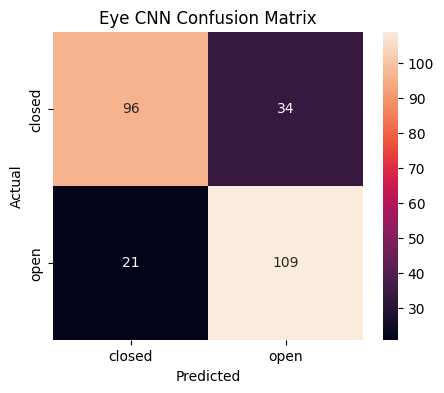

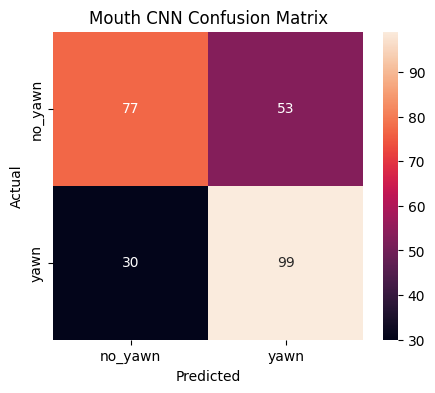

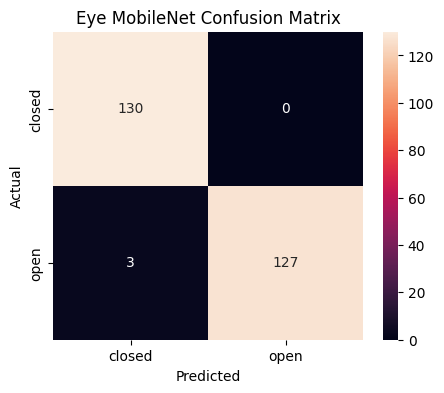

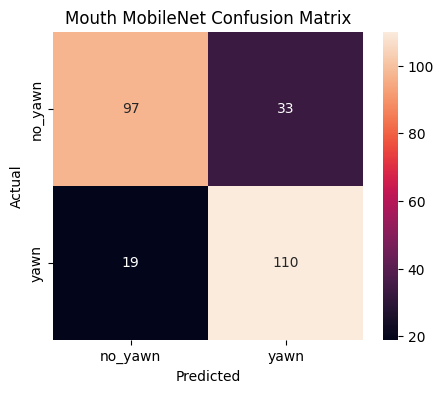

In [79]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# Utility Function
# ==============================
def plot_cm(model, data, title):

    # 🔥 Reset generator (VERY IMPORTANT)
    data.reset()

    y_true = data.classes
    y_pred = np.argmax(model.predict(data, verbose=0), axis=1)

    class_labels = list(data.class_indices.keys())

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=class_labels,
                yticklabels=class_labels)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# ==============================
# CNN MODELS
# ==============================

plot_cm(eye_model, eye_test, "Eye CNN Confusion Matrix")
plot_cm(mouth_model, mouth_test, "Mouth CNN Confusion Matrix")

# ==============================
# MOBILENET MODELS
# ==============================

plot_cm(eye_mobilenet, eye_test, "Eye MobileNet Confusion Matrix")
plot_cm(mouth_mobilenet, mouth_test, "Mouth MobileNet Confusion Matrix")

In [80]:
import numpy as np

# ==============================
# EYE DATA
# ==============================

# 🔥 Reset generator (VERY IMPORTANT)
eye_test.reset()

eye_true = eye_test.classes
eye_class_names = list(eye_test.class_indices.keys())

# CNN
eye_pred_cnn = np.argmax(
    eye_model.predict(eye_test, verbose=0), axis=1
)

# 🔥 Reset again before next model
eye_test.reset()

# MobileNet
eye_pred_mob = np.argmax(
    eye_mobilenet.predict(eye_test, verbose=0), axis=1
)


# ==============================
# MOUTH DATA
# ==============================

mouth_test.reset()

mouth_true = mouth_test.classes
mouth_class_names = list(mouth_test.class_indices.keys())

# CNN
mouth_pred_cnn = np.argmax(
    mouth_model.predict(mouth_test, verbose=0), axis=1
)

# 🔥 Reset again
mouth_test.reset()

# MobileNet
mouth_pred_mob = np.argmax(
    mouth_mobilenet.predict(mouth_test, verbose=0), axis=1
)


print("✅ Predictions ready (aligned correctly)")

✅ Predictions ready (aligned correctly)


In [31]:
from sklearn.metrics import classification_report
import numpy as np

# ==============================
# EYE MODEL (MobileNet)
# ==============================

# 🔥 VERY IMPORTANT
eye_test.reset()

eye_true = eye_test.classes

eye_pred = np.argmax(
    eye_mobilenet.predict(eye_test, verbose=0),
    axis=1
)

class_names = list(eye_test.class_indices.keys())

print("\n===== Eye Model Report =====")
print(classification_report(
    eye_true,
    eye_pred,
    target_names=class_names,
    zero_division=0   # avoids warnings
))


===== Eye Model Report =====
              precision    recall  f1-score   support

      closed       0.99      1.00      1.00       130
        open       1.00      0.99      1.00       130

    accuracy                           1.00       260
   macro avg       1.00      1.00      1.00       260
weighted avg       1.00      1.00      1.00       260



In [81]:
from sklearn.metrics import classification_report
import numpy as np

# ==============================
# EYE CNN
# ==============================
eye_test.reset()

eye_true = eye_test.classes
eye_pred_cnn = np.argmax(
    eye_model.predict(eye_test, verbose=0), axis=1
)

print("\n===== Eye CNN Classification Report =====")
print(classification_report(
    eye_true,
    eye_pred_cnn,
    target_names=list(eye_test.class_indices.keys()),
    zero_division=0
))


# ==============================
# MOUTH CNN
# ==============================
mouth_test.reset()

mouth_true = mouth_test.classes
mouth_pred_cnn = np.argmax(
    mouth_model.predict(mouth_test, verbose=0), axis=1
)

print("\n===== Mouth CNN Classification Report =====")
print(classification_report(
    mouth_true,
    mouth_pred_cnn,
    target_names=list(mouth_test.class_indices.keys()),
    zero_division=0
))


# ==============================
# EYE MOBILENET
# ==============================
eye_test.reset()

eye_pred_mob = np.argmax(
    eye_mobilenet.predict(eye_test, verbose=0), axis=1
)

print("\n===== Eye MobileNet Classification Report =====")
print(classification_report(
    eye_true,
    eye_pred_mob,
    target_names=list(eye_test.class_indices.keys()),
    zero_division=0
))


# ==============================
# MOUTH MOBILENET
# ==============================
mouth_test.reset()

mouth_pred_mob = np.argmax(
    mouth_mobilenet.predict(mouth_test, verbose=0), axis=1
)

print("\n===== Mouth MobileNet Classification Report =====")
print(classification_report(
    mouth_true,
    mouth_pred_mob,
    target_names=list(mouth_test.class_indices.keys()),
    zero_division=0
))


===== Eye CNN Classification Report =====
              precision    recall  f1-score   support

      closed       0.82      0.74      0.78       130
        open       0.76      0.84      0.80       130

    accuracy                           0.79       260
   macro avg       0.79      0.79      0.79       260
weighted avg       0.79      0.79      0.79       260


===== Mouth CNN Classification Report =====
              precision    recall  f1-score   support

     no_yawn       0.72      0.59      0.65       130
        yawn       0.65      0.77      0.70       129

    accuracy                           0.68       259
   macro avg       0.69      0.68      0.68       259
weighted avg       0.69      0.68      0.68       259


===== Eye MobileNet Classification Report =====
              precision    recall  f1-score   support

      closed       0.98      1.00      0.99       130
        open       1.00      0.98      0.99       130

    accuracy                           0.99  

In [82]:
def fatigue_level(eye_label, mouth_label):

    # Normalize (avoid case issues)
    eye_label = eye_label.lower()
    mouth_label = mouth_label.lower()

    if eye_label == 'open' and mouth_label == 'no_yawn':
        return "Alert"

    elif eye_label == 'open' and mouth_label == 'yawn':
        return "Mild Fatigue"

    elif eye_label == 'closed' and mouth_label == 'no_yawn':
        return "Moderate Fatigue"

    elif eye_label == 'closed' and mouth_label == 'yawn':
        return "Severe Fatigue"

    else:
        return "Uncertain"

In [83]:
# ==============================
# Fatigue Detection Logic (Fixed)
# ==============================

def fatigue_level(eye_label, mouth_label):
    eye_label = eye_label.lower()
    mouth_label = mouth_label.lower()

    if eye_label == 'open' and mouth_label == 'no_yawn':
        return "Alert"

    elif eye_label == 'open' and mouth_label == 'yawn':
        return "Mild Fatigue"

    elif eye_label == 'closed' and mouth_label == 'no_yawn':
        return "Moderate Fatigue"

    elif eye_label == 'closed' and mouth_label == 'yawn':
        return "Severe Fatigue"

    else:
        return "Uncertain"

In [84]:
# ==============================
# Ensure predictions exist
# ==============================

eye_test.reset()
mouth_test.reset()

import numpy as np

eye_pred_mob = np.argmax(eye_mobilenet.predict(eye_test, verbose=0), axis=1)
mouth_pred_mob = np.argmax(mouth_mobilenet.predict(mouth_test, verbose=0), axis=1)

# ==============================
# Convert to labels
# ==============================

eye_labels = list(eye_test.class_indices.keys())
mouth_labels = list(mouth_test.class_indices.keys())

# Use minimum length (safe fix)
min_len = min(len(eye_pred_mob), len(mouth_pred_mob))

eye_pred_labels = [eye_labels[i] for i in eye_pred_mob[:min_len]]
mouth_pred_labels = [mouth_labels[i] for i in mouth_pred_mob[:min_len]]

# ==============================
# Fatigue Logic
# ==============================

def fatigue_level(eye, mouth):
    eye = eye.lower()
    mouth = mouth.lower()

    if eye == 'open' and mouth == 'no_yawn':
        return "Alert"
    elif eye == 'open' and mouth == 'yawn':
        return "Mild Fatigue"
    elif eye == 'closed' and mouth == 'no_yawn':
        return "Moderate Fatigue"
    elif eye == 'closed' and mouth == 'yawn':
        return "Severe Fatigue"
    else:
        return "Uncertain"

# ==============================
# Generate fatigue_results
# ==============================

fatigue_results = [
    fatigue_level(e, m)
    for e, m in zip(eye_pred_labels, mouth_pred_labels)
]

print("✅ fatigue_results ready")

✅ fatigue_results ready


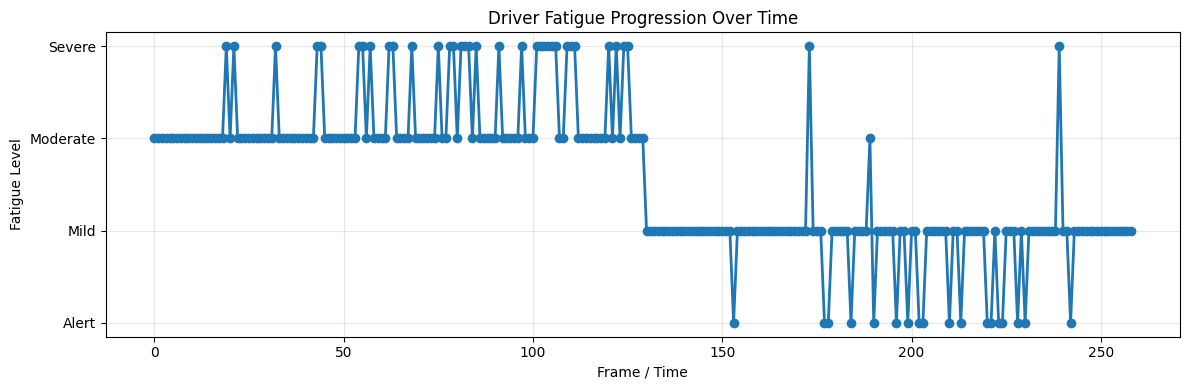

In [85]:
import matplotlib.pyplot as plt

# ==============================
# Mapping (FIXED)
# ==============================
mapping = {
    "Alert": 0,
    "Mild Fatigue": 1,
    "Moderate Fatigue": 2,
    "Severe Fatigue": 3
}

values = [mapping.get(f, 0) for f in fatigue_results]

# ==============================
# Plot
# ==============================
plt.figure(figsize=(12,4))

plt.plot(values, marker='o', linestyle='-', linewidth=2)

plt.title("Driver Fatigue Progression Over Time")
plt.xlabel("Frame / Time")
plt.ylabel("Fatigue Level")

# ✅ Correct labels
plt.yticks(
    [0,1,2,3],
    ["Alert", "Mild", "Moderate", "Severe"]
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [86]:
!pip install streamlit

In [87]:
!pip install streamlit pyngrok --quiet

In [114]:
%%writefile app.py
import streamlit as st
import numpy as np
import cv2
from PIL import Image
from tensorflow.keras.models import load_model
import mediapipe as mp

# ==============================
# CONFIG
# ==============================
st.set_page_config(page_title="Driver Drowsiness Detection", page_icon="🚗")
st.title("🚗 Driver Drowsiness Detection")

# ==============================
# LOAD MODELS
# ==============================
@st.cache_resource
def load_models():
    return load_model("eye_mobilenet.keras"), load_model("mouth_mobilenet.keras")

eye_model, mouth_model = load_models()

eye_classes = ['closed', 'open']
mouth_classes = ['no_yawn', 'yawn']

# ==============================
# MEDIAPIPE
# ==============================
@st.cache_resource
def load_mp():
    return mp.solutions.face_mesh.FaceMesh(static_image_mode=True)

face_mesh = load_mp()

# ==============================
# PREPROCESS
# ==============================
def preprocess(img):
    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    return np.expand_dims(img, axis=0)

# ==============================
# EYE VISIBILITY
# ==============================
def is_eye_visible(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return np.var(gray) > 50

# ==============================
# NORMALIZED MOUTH RATIO
# ==============================
def mouth_open_ratio(lm):
    top = lm[13]
    bottom = lm[14]
    left = lm[78]
    right = lm[308]

    vertical = abs(bottom.y - top.y)
    horizontal = abs(right.x - left.x)

    if horizontal == 0:
        return 0

    return vertical / horizontal

# ==============================
# GET REGIONS
# ==============================
def get_regions(img):
    h, w, _ = img.shape
    results = face_mesh.process(cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

    if not results.multi_face_landmarks:
        return None, None, None

    lm = results.multi_face_landmarks[0].landmark

    def crop(indices, pad=25):
        xs = [int(lm[i].x * w) for i in indices]
        ys = [int(lm[i].y * h) for i in indices]

        x1, x2 = max(0, min(xs)-pad), min(w, max(xs)+pad)
        y1, y2 = max(0, min(ys)-pad), min(h, max(ys)+pad)

        crop = img[y1:y2, x1:x2]
        return crop if crop.size > 0 else None

    eye_idx = [33,133,160,159,158,157,173]
    mouth_idx = [13,14,78,308]

    return crop(eye_idx), crop(mouth_idx), lm

# ==============================
# FINAL FATIGUE LOGIC
# ==============================
def fatigue_logic(eye_label, mouth_label, eye_conf):

    if eye_label == "Unknown" or eye_conf < 0.80:
        return "Mild Fatigue" if mouth_label == "Yawn" else "Alert"

    if eye_label == "Open" and mouth_label == "No Yawn":
        return "Alert"

    if eye_label == "Open" and mouth_label == "Yawn":
        return "Mild Fatigue"

    if eye_label == "Closed" and mouth_label == "Yawn":
        return "Severe Fatigue"

    if eye_label == "Closed":
        return "Moderate Fatigue"

    return "Moderate Fatigue"

# ==============================
# UPLOAD
# ==============================
file = st.file_uploader("Upload Image", type=["jpg","png","jpeg"])

if file:

    img = np.array(Image.open(file).convert("RGB"))
    st.image(img, use_container_width=True)

    eye_img, mouth_img, lm = get_regions(img)

    if eye_img is None or mouth_img is None:
        st.warning("⚠ Face not detected. Using full image.")
        eye_img, mouth_img = img, img
        use_geo = False
    else:
        use_geo = True

    # ==============================
    # EYE
    # ==============================
    if not is_eye_visible(eye_img):
        eye_label = "Unknown"
        eye_conf = 0.0
    else:
        ep = eye_model.predict(preprocess(eye_img), verbose=0)[0]
        ei = np.argmax(ep)
        eye_conf = float(np.max(ep))
        eye_label = eye_classes[ei].title()

    # ==============================
    # MOUTH (🔥 FINAL FIX)
    # ==============================
    mpred = mouth_model.predict(preprocess(mouth_img), verbose=0)[0]
    mi = np.argmax(mpred)
    mouth_conf = float(np.max(mpred))

    if use_geo:
        ratio = mouth_open_ratio(lm)

        if ratio > 0.32 and mouth_conf > 0.80:
            mouth_label = "Yawn"
        elif ratio > 0.40:
            mouth_label = "Yawn"
        else:
            mouth_label = "No Yawn"
    else:
        mouth_label = mouth_classes[mi].replace("_"," ").title()

    # ==============================
    # FATIGUE
    # ==============================
    fatigue = fatigue_logic(eye_label, mouth_label, eye_conf)

    st.write("---")

    c1, c2 = st.columns(2)
    c1.metric("👁 Eye", eye_label, f"{eye_conf:.2f}")
    c2.metric("👄 Mouth", mouth_label, f"{mouth_conf:.2f}")

    st.write("---")

    # ==============================
    # ALERT
    # ==============================
    if fatigue == "Severe Fatigue":
        st.error("🚨 Severe Fatigue Detected!")
    elif fatigue == "Moderate Fatigue":
        st.warning("⚠ Moderate Fatigue")
    elif fatigue == "Mild Fatigue":
        st.info("😴 Mild Fatigue")
    else:
        st.success("✅ Alert")

    st.write("### Confidence")
    st.progress(int(eye_conf*100))
    st.progress(int(mouth_conf*100))

Writing app.py


In [115]:
!streamlit run app.py &>/dev/null&

In [116]:
!ngrok authtoken 36IeTvr7PlB5X7b8Kv3Kfw6FF9r_7DoFqQJNdrUww2ADZ5jFq

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [104]:
!pkill ngrok

In [117]:
from pyngrok import ngrok
public_url = ngrok.connect(8501)
print("Click this link:", public_url)

Click this link: NgrokTunnel: "https://unreducible-twanda-unconsumptive.ngrok-free.dev" -> "http://localhost:8501"


In [62]:
print(eye_train.class_indices)
print(mouth_train.class_indices)

{'closed': 0, 'open': 1}
{'no_yawn': 0, 'yawn': 1}


In [54]:
import os
print(os.listdir())

['.config', 'mouth', 'mouth_mobilenet.keras', 'app.py', 'dataset', 'eye_mobilenet.keras', '.ipynb_checkpoints', 'best_eye_model.keras', 'eye_model.keras', 'best_mouth_model.keras', 'eye', 'mouth_model.keras', 'archive (2).zip', 'sample_data']
